<a href="https://colab.research.google.com/github/nastya-kolle/cars-fuel-efficiency-regression/blob/main/Cars_Regression_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Задачи:**
* построить минимум две регрессионные модели регрессии (линейную и нелинейную,
приведенную к линейной с помощью линеаризации) взаимосвязи целевого показателя
mpg и других факторов (cylinders, displacement, horsepower, weight, acceleration, model year,
origin, car name);
* сравнить качество построенных моделей;
* сделать прогноз.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import scipy
import scipy.stats as stats
import seaborn as sns

In [4]:
cars=pd.read_csv('auto-mpg.csv')

In [5]:
cars.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


Предоставлены данные моделей автомобилей с некоторыми их характеристиками, собранные в
1983 году в университете Карнеги-Мелон. Информация, содержащаяся в датасете:
* mpg – расход топлива (в милях на галлон);
* cylinders – число цилиндров в двигателе;
* displacement – объем двигателя (в кубических дюймах);
* horsepower – мощность (в лошадиных силах);
* weight – масса автомобиля (в фунтах);
* acceleration – разгон до 60 миль/час (в секундах);
* model year – год выпуска модели;
* origin – регион производства (1 – США, 2 – Европа, 3 – Юго-Восточная Азия);
* car name – наименование модели.


In [6]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


**Шаг 1.** Подготовить данные для анализа:
* работа с пропусками;
* работа с дубликатами;
* обработка некорректной информации


**Шаг 2.** Определить типы данных и шкалы.

Типы данных в наборе:

*   Категориальный (категоризованный):origin,model year
*   Категориальный (некатегоризованный):car name
*   Количественный :mpg,displacement,acceleration,cylinders,horsepower,weight



In [7]:
cars["horsepower"] = pd.to_numeric(cars["horsepower"].astype(str).str.replace(r"[^\d\-]", ""), errors="coerce")

In [8]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 28.1+ KB


In [9]:
cars[cars['horsepower'].isnull()]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
32,25.0,4,98.0,NaN,2046,19.0,71,1,ford pinto
126,21.0,6,200.0,NaN,2875,17.0,74,1,ford maverick
330,40.9,4,85.0,NaN,1835,17.3,80,2,renault lecar deluxe
336,23.6,4,140.0,NaN,2905,14.3,80,1,ford mustang cobra
354,34.5,4,100.0,NaN,2320,15.8,81,2,renault 18i
374,23.0,4,151.0,NaN,3035,20.5,82,1,amc concord dl


In [10]:
cars[cars['horsepower'].notnull()].groupby('origin').agg({'horsepower': ['mean', 'count']})

horsepower      
              mean count
origin                  
1       119.048980   245
2        80.558824    68
3        79.835443    79

In [11]:
cars[cars['horsepower'].notnull()].groupby('model year').agg({'horsepower': ['mean', 'count']})

horsepower      
                  mean count
model year                  
70          147.827586    29
71          107.037037    27
72          120.178571    28
73          130.475000    40
74           94.230769    26
75          101.066667    30
76          101.117647    34
77          105.071429    28
78           99.694444    36
79          101.206897    29
80           77.481481    27
81           81.035714    28
82           81.466667    30

In [12]:
for i in range (len(cars)):
  if cars.at[i,'horsepower'] > 0:
    cars.at[i,'horsepower_new'] = cars.at[i,'horsepower']
  else:
    cars.at[i,'horsepower_new']=cars[(cars['model year']==cars.loc[i,'model year'])&(cars['horsepower'].notnull())]['horsepower'].mean()


In [13]:
cars.iloc[336]

,336
mpg,23.6
cylinders,4
displacement,140.0
horsepower,NaN
weight,2905
acceleration,14.3
model year,80
origin,1
car name,ford mustang cobra
horsepower_new,77.481481


In [14]:
cars.iloc[2]

,2
mpg,18.0
cylinders,8
displacement,318.0
horsepower,150.0
weight,3436
acceleration,11.0
model year,70
origin,1
car name,plymouth satellite
horsepower_new,150.0


In [15]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mpg             398 non-null    float64
 1   cylinders       398 non-null    int64  
 2   displacement    398 non-null    float64
 3   horsepower      392 non-null    float64
 4   weight          398 non-null    int64  
 5   acceleration    398 non-null    float64
 6   model year      398 non-null    int64  
 7   origin          398 non-null    int64  
 8   car name        398 non-null    object 
 9   horsepower_new  398 non-null    float64
dtypes: float64(5), int64(4), object(1)
memory usage: 31.2+ KB


In [16]:
cars.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,horsepower_new
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864,104.197822
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055,38.285375
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000,46.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000,76.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000,92.500000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000,125.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000,230.000000


In [17]:
cars['origin'].value_counts()

,count
origin,
1,249
3,79
2,70


**Анализ взаимосвязи количественных признаков**

In [18]:
col=['mpg','cylinders','displacement','weight','acceleration', 'horsepower_new']
cars[col].corr(method='pearson') # количественная корреляция Пирсона

,mpg,cylinders,displacement,weight,acceleration,horsepower_new
mpg,1.000000,-0.775396,-0.804203,-0.831741,0.420289,-0.775488
cylinders,-0.775396,1.000000,0.950721,0.896017,-0.505419,0.842340
displacement,-0.804203,0.950721,1.000000,0.932824,-0.543684,0.896191
weight,-0.831741,0.896017,0.932824,1.000000,-0.417457,0.862115
acceleration,0.420289,-0.505419,-0.543684,-0.417457,1.000000,-0.685993
horsepower_new,-0.775488,0.842340,0.896191,0.862115,-0.685993,1.000000


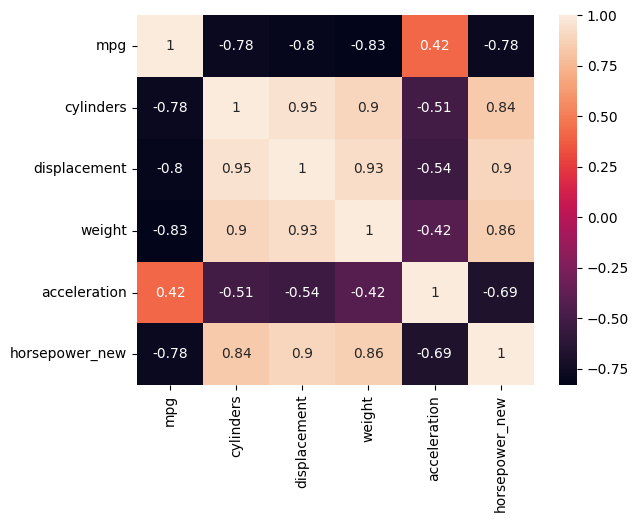

In [19]:
sns.heatmap(cars[col].corr(),annot=True);

**Оценка параметров модели**

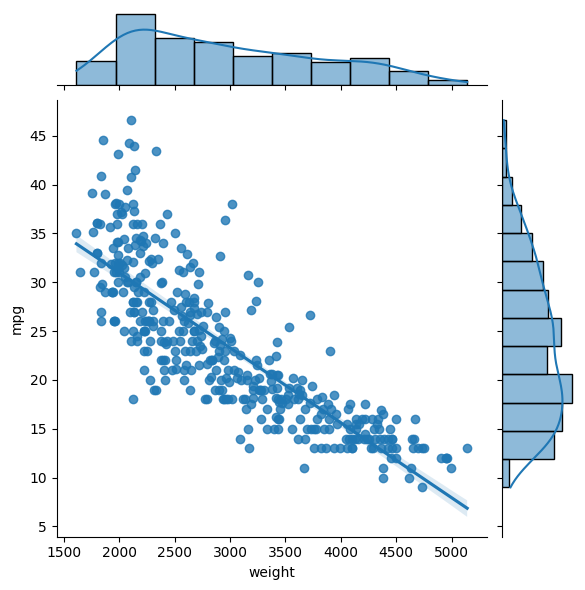

In [20]:
sns.jointplot(x='weight', y='mpg', data=cars,kind='reg')

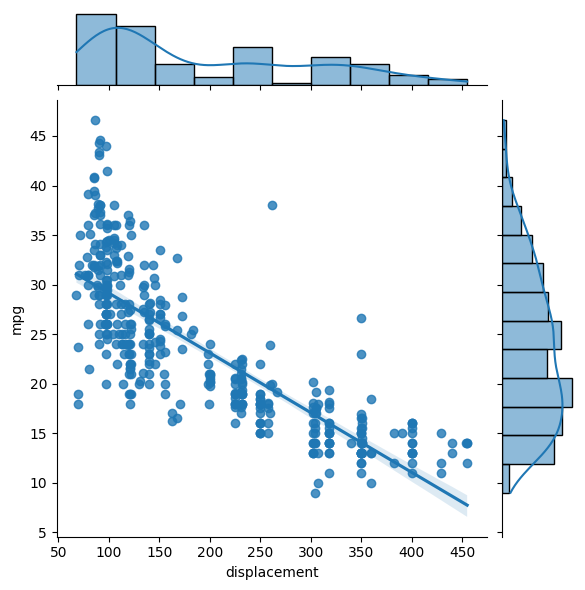

In [21]:
sns.jointplot(x='displacement', y='mpg', data=cars,kind='reg')

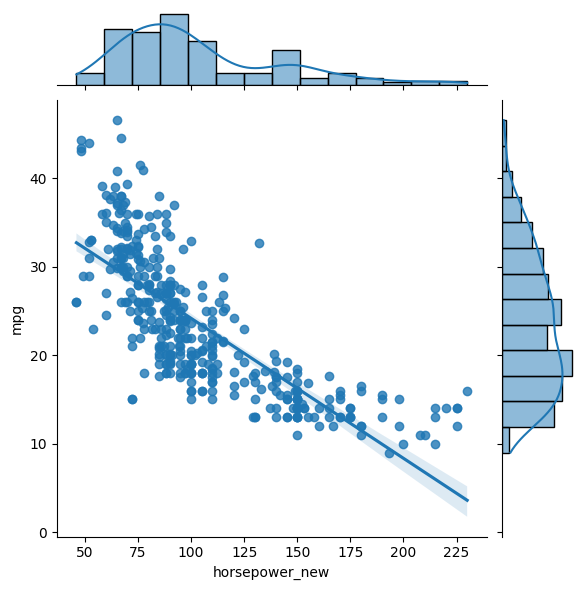

In [22]:
sns.jointplot(x='horsepower_new', y='mpg', data=cars,kind='reg')

Степенная: $Y=ax^bɛ$

Логарифмирование: $\ln Y=\ln(ax^bɛ)$ => $\ln Y=\ln a+b\ln x+\ln ɛ$

Замена: $Y_1=\ln Y$, $x_1=\ln x$

Что получим: $Y_1=\ln a+bx_1+\ln ɛ$

In [23]:
cars['mpg1']=np.log(cars['mpg'])
cars['displacement1']=np.log(cars['displacement'])
cars['weight1']=np.log(cars['weight'])
cars['horsepower_new1']=np.log(cars['horsepower_new'])

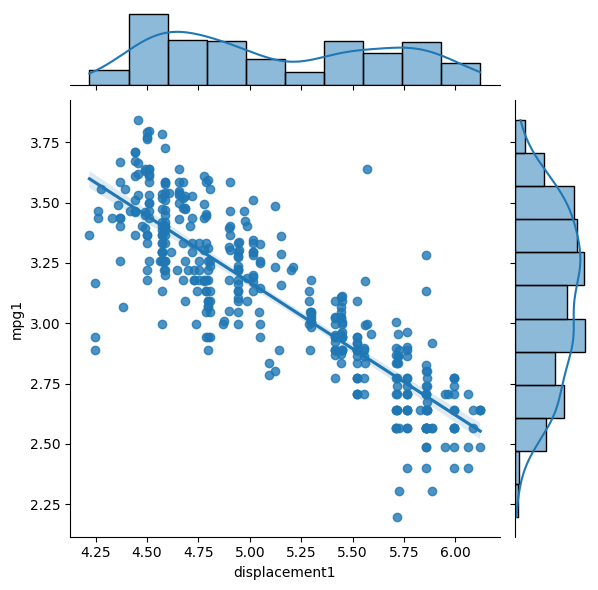

In [24]:
sns.jointplot(x='displacement1', y='mpg1', data=cars,kind='reg')

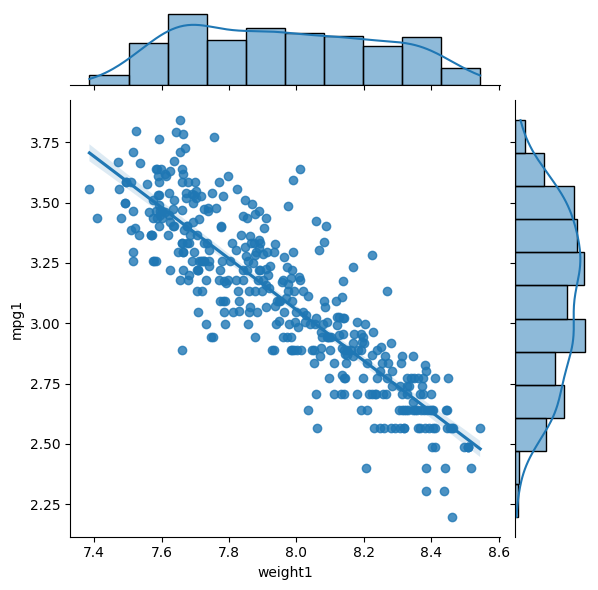

In [25]:
sns.jointplot(x='weight1',y='mpg1',data=cars,kind='reg')

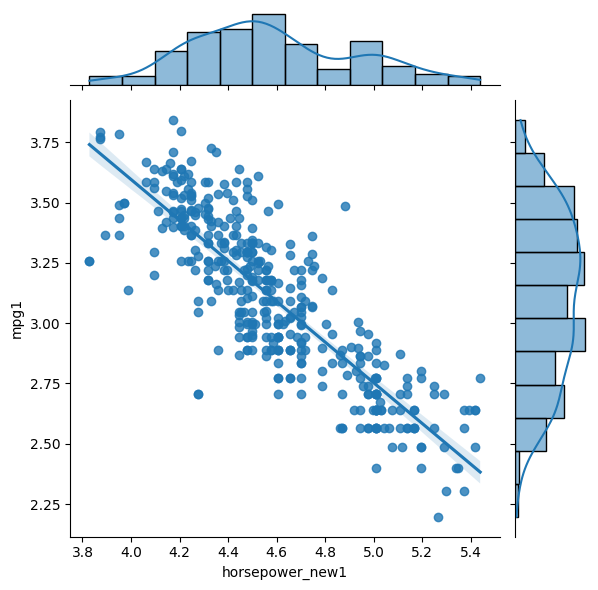

In [26]:
sns.jointplot(x='horsepower_new1',y='mpg1',data=cars,kind='reg')

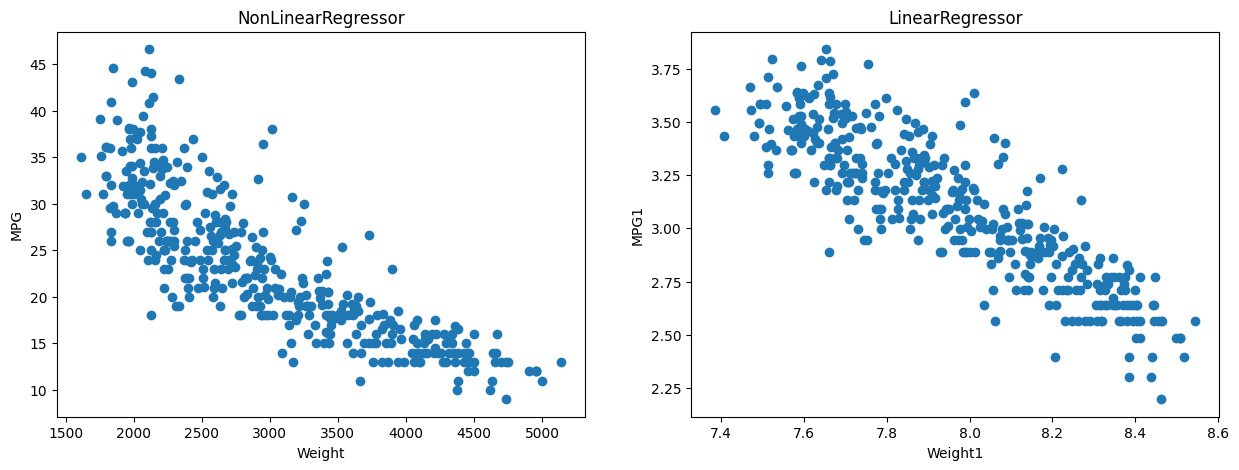

In [27]:
fig, (ax1, ax2)=plt.subplots(nrows=1,ncols=2,figsize=(15,5))
ax1.scatter(x=cars['weight'], y=cars['mpg'])
ax1.set_title('NonLinearRegressor')
ax1.set_xlabel('Weight')
ax1.set_ylabel('MPG')

ax2.scatter(x=cars['weight1'], y=cars['mpg1'])
ax2.set_title('LinearRegressor')
ax2.set_xlabel('Weight1')
ax2.set_ylabel('MPG1')

plt.show()

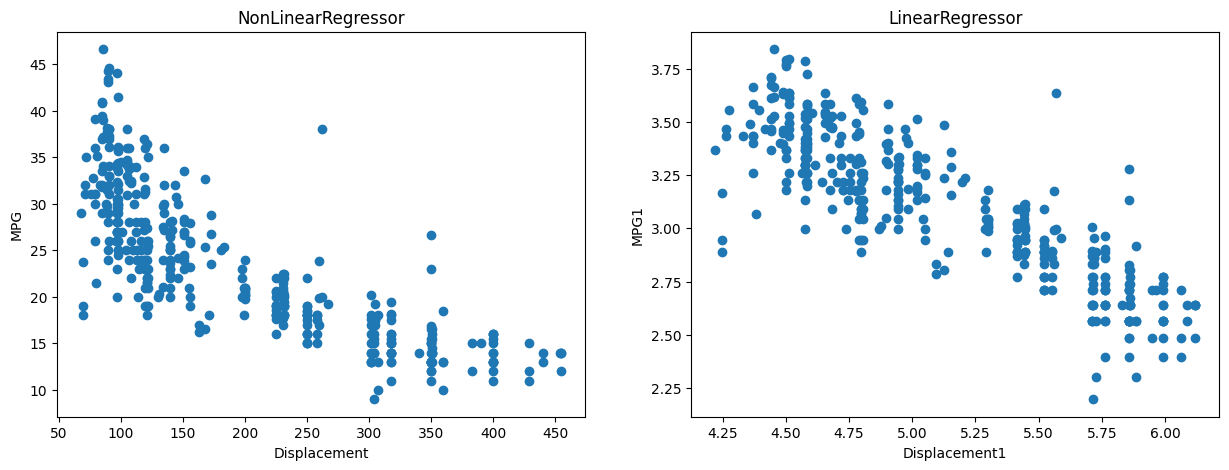

In [28]:
fig, (ax1, ax2)=plt.subplots(nrows=1,ncols=2,figsize=(15,5))
ax1.scatter(x=cars['displacement'], y=cars['mpg'])
ax1.set_title('NonLinearRegressor')
ax1.set_xlabel('Displacement')
ax1.set_ylabel('MPG')

ax2.scatter(x=cars['displacement1'], y=cars['mpg1'])
ax2.set_title('LinearRegressor')
ax2.set_xlabel('Displacement1')
ax2.set_ylabel('MPG1')

plt.show()

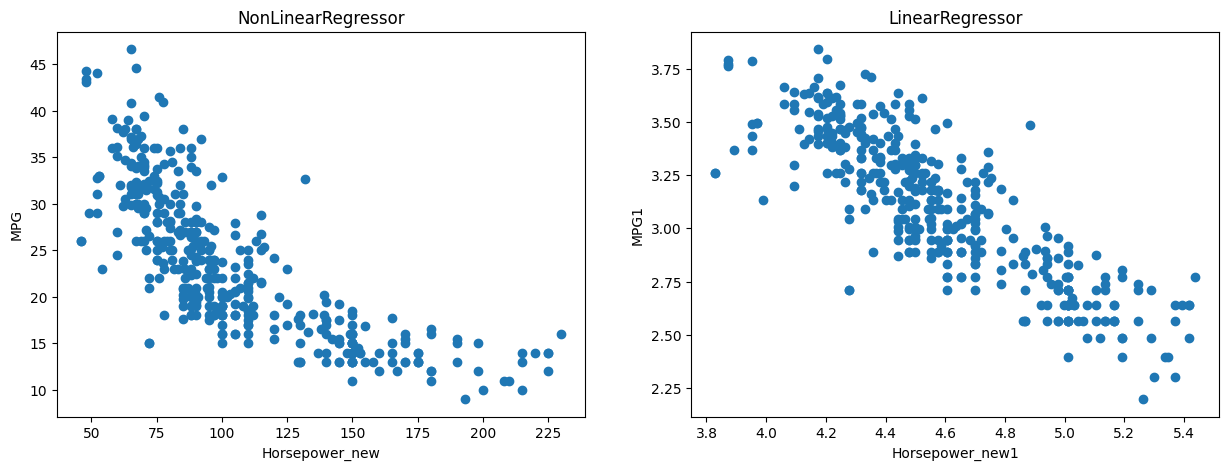

In [29]:
fig, (ax1, ax2)=plt.subplots(nrows=1,ncols=2,figsize=(15,5))
ax1.scatter(x=cars['horsepower_new'], y=cars['mpg'])
ax1.set_title('NonLinearRegressor')
ax1.set_xlabel('Horsepower_new')
ax1.set_ylabel('MPG')

ax2.scatter(x=cars['horsepower_new1'], y=cars['mpg1'])
ax2.set_title('LinearRegressor')
ax2.set_xlabel('Horsepower_new1')
ax2.set_ylabel('MPG1')

plt.show()

**Линейная регрессия**

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score

In [31]:
Y1=cars['mpg']#зависимая (целевая) переменная
X1=cars[['weight','horsepower_new','origin']]#независимые факторы
X1_train, X1_test, Y1_train, Y1_test=train_test_split(X1, Y1,test_size=0.2,random_state=0)

In [32]:
print('Number of data :', cars.shape[0])
print('Number of train data :',X1_train.shape[0])
print('Number of test data :', X1_test.shape[0])

Number of data : 398
Number of train data : 318
Number of test data : 80


In [33]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import sklearn.linear_model as lm

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['weight', 'horsepower_new']),  # масштабируем числовые
        ('cat', OneHotEncoder(drop='first', sparse_output=False), ['origin'])  # one-hot для origin
    ],
    remainder='drop'  # остальные признаки не нужны
)

X1_train_prep = preprocessor.fit_transform(X1_train)
X1_test_prep = preprocessor.transform(X1_test)

LR = lm.LinearRegression()
model1 = LR.fit(X1_train_prep, Y1_train)

Y1_train_pred = model1.predict(X1_train_prep)
Y1_test_pred = model1.predict(X1_test_prep)

In [34]:
#import sklearn.linear_model as lm

In [35]:
#LR=lm.LinearRegression()

In [36]:
#model1=LR.fit(X1_train, Y1_train)

In [37]:
#Y1_train_pred=model1.predict(X1_train)
#Y1_test_pred=model1.predict(X1_test)

In [38]:
QualityMetrics=['R2 train', 'R2 test', 'MSE train', 'MSE test']
Models=pd.DataFrame(index=QualityMetrics)
Models.at[QualityMetrics,'LinearRegressor']=[r2_score(Y1_train, Y1_train_pred),
                                             r2_score(Y1_test, Y1_test_pred),
                                             mean_squared_error(Y1_train, Y1_train_pred),
                                             mean_squared_error(Y1_test, Y1_test_pred)]

In [39]:
Models

,LinearRegressor
R2 train,0.717325
R2 test,0.711766
MSE train,17.040725
MSE test,18.290582


**Нелинейная регрессия с применением линеаризации**

In [40]:
Y2=cars['mpg1']
X2=cars[['weight1', 'horsepower_new1','origin']]
X2_train, X2_test, Y2_train, Y2_test=train_test_split(X2, Y2, test_size=0.2, random_state=0)

preprocessor2 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['weight1', 'horsepower_new1']),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), ['origin'])
    ],
    remainder='drop'
)

X2_train_prep = preprocessor2.fit_transform(X2_train)
X2_test_prep = preprocessor2.transform(X2_test)

model2 = LR.fit(X2_train_prep, Y2_train)
Y2_train_pred = model2.predict(X2_train_prep)
Y2_test_pred = model2.predict(X2_test_prep)

Models.at[QualityMetrics, 'NonLinearRegressor']=[r2_score(Y2_train, Y2_train_pred),
                                                 r2_score(Y2_test, Y2_test_pred),
                                                 mean_squared_error(np.exp(Y2_train), np.exp(Y2_train_pred)),
                                                 mean_squared_error(np.exp(Y2_test), np.exp(Y2_test_pred))]

In [41]:
Models

,LinearRegressor,NonLinearRegressor
R2 train,0.717325,0.799476
R2 test,0.711766,0.794014
MSE train,17.040725,15.399581
MSE test,18.290582,16.703782


In [42]:
Y4=cars['mpg']
X4=cars[['weight', 'horsepower_new','origin','displacement','cylinders', 'acceleration', 'model year']]
X4_train, X4_test, Y4_train, Y4_test=train_test_split(X4, Y4, test_size=0.2, random_state=0)

preprocessor_3 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['weight', 'horsepower_new', 'displacement', 'cylinders', 'acceleration', 'model year']),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), ['origin'])
    ],
    remainder='drop'
)

X4_train_prep = preprocessor_3.fit_transform(X4_train)
X4_test_prep = preprocessor_3.transform(X4_test)

model4=LR.fit(X4_train_prep, Y4_train)
Y4_train_pred=model4.predict(X4_train_prep)
Y4_test_pred=model4.predict(X4_test_prep)
Models.at[QualityMetrics, 'LinearRegressor_full']=[r2_score(Y4_train, Y4_train_pred),
                                                 r2_score(Y4_test, Y4_test_pred),
                                                 mean_squared_error(Y4_train, Y4_train_pred),
                                                 mean_squared_error(Y4_test, Y4_test_pred)]
Models

,LinearRegressor,NonLinearRegressor,LinearRegressor_full
R2 train,0.717325,0.799476,0.821132
R2 test,0.711766,0.794014,0.828304
MSE train,17.040725,15.399581,10.782819
MSE test,18.290582,16.703782,10.895389


In [43]:
Y3=cars['mpg1']
X3=cars[['weight1', 'displacement1','horsepower_new1','origin','cylinders', 'acceleration', 'model year']]
X3_train, X3_test, Y3_train, Y3_test=train_test_split(X3, Y3, test_size=0.2, random_state=0)

preprocessor_4 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['weight1', 'displacement1', 'horsepower_new1', 'cylinders', 'acceleration', 'model year']),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), ['origin'])
    ],
    remainder='drop'
)

X3_train_prep = preprocessor_4.fit_transform(X3_train)
X3_test_prep = preprocessor_4.transform(X3_test)

model3=LR.fit(X3_train_prep, Y3_train)
Y3_train_pred=model3.predict(X3_train_prep)
Y3_test_pred=model3.predict(X3_test_prep)

Models.at[QualityMetrics, 'NonLinearRegressor_full']=[r2_score(Y3_train, Y3_train_pred),
                                                 r2_score(Y3_test, Y3_test_pred),
                                                 mean_squared_error(np.exp(Y3_train), np.exp(Y3_train_pred)),
                                                 mean_squared_error(np.exp(Y3_test), np.exp(Y3_test_pred))]
Models

,LinearRegressor,NonLinearRegressor,LinearRegressor_full,NonLinearRegressor_full
R2 train,0.717325,0.799476,0.821132,0.888244
R2 test,0.711766,0.794014,0.828304,0.895777
MSE train,17.040725,15.399581,10.782819,8.068044
MSE test,18.290582,16.703782,10.895389,7.466817


## Полиномиальная модель регрессии с аргументами

Y5=cars['mpg']


X5=cars[['weight','horsepower_new','origin']]


In [44]:
from sklearn.preprocessing import PolynomialFeatures

In [45]:
Y5=cars['mpg']#зависимая (целевая) переменная
X5=cars[['weight','horsepower_new','origin']]#независимые факторы
X5_train, X5_test, Y5_train, Y5_test=train_test_split(X5, Y5,test_size=0.2,random_state=0)

In [46]:
from sklearn.pipeline import Pipeline

preprocessor_poly = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['weight', 'horsepower_new']),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), ['origin'])
    ],
    remainder='drop'
)

poly_features = PolynomialFeatures(degree=3, include_bias=False)

pipeline_poly = Pipeline(steps=[
    ('preprocessor', preprocessor_poly),
    ('poly', poly_features),
    ('regressor', lm.LinearRegression())
])

pipeline_poly.fit(X5_train, Y5_train)

Y5_train_pred = pipeline_poly.predict(X5_train)
Y5_test_pred = pipeline_poly.predict(X5_test)

In [47]:
Models.at[QualityMetrics,'Polynomial Model']=[r2_score(Y5_train, Y5_train_pred),
                                              r2_score(Y5_test, Y5_test_pred),
                                              mean_squared_error(Y5_train, Y5_train_pred),
                                              mean_squared_error(Y5_test, Y5_test_pred)]
Models

,LinearRegressor,NonLinearRegressor,LinearRegressor_full,NonLinearRegressor_full,Polynomial Model
R2 train,0.717325,0.799476,0.821132,0.888244,0.787744
R2 test,0.711766,0.794014,0.828304,0.895777,0.724801
MSE train,17.040725,15.399581,10.782819,8.068044,12.795563
MSE test,18.290582,16.703782,10.895389,7.466817,17.463379


## Полиномиальная модель регресии с аргументами

Y6=cars['mpg']


X6=cars[['weight', 'horsepower_new','origin','displacement','cylinders', 'acceleration', 'model year']]

In [48]:
Y6=cars['mpg']
X6=cars[['weight', 'horsepower_new','origin','displacement','cylinders', 'acceleration', 'model year']]
X6_train, X6_test, Y6_train, Y6_test=train_test_split(X6, Y6,test_size=0.2,random_state=0)

In [49]:
preprocessor_poly_full = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['weight', 'horsepower_new', 'displacement', 'cylinders', 'acceleration', 'model year']),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), ['origin'])
    ],
    remainder='drop'
)

poly_features_full = PolynomialFeatures(degree=3)

pipeline_poly_full = Pipeline(steps=[
    ('preprocessor', preprocessor_poly_full),
    ('poly', poly_features_full),
    ('regressor', lm.LinearRegression())
])

pipeline_poly_full.fit(X6_train, Y6_train)

Y6_train_pred = pipeline_poly_full.predict(X6_train)
Y6_test_pred = pipeline_poly_full.predict(X6_test)

In [50]:
Models.at[QualityMetrics,'Polynomial Model_full']=[r2_score(Y6_train, Y6_train_pred),
                                              r2_score(Y6_test, Y6_test_pred),
                                              mean_squared_error(Y6_train, Y6_train_pred),
                                              mean_squared_error(Y6_test, Y6_test_pred)]
Models

,LinearRegressor,NonLinearRegressor,LinearRegressor_full,NonLinearRegressor_full,Polynomial Model,Polynomial Model_full
R2 train,0.717325,0.799476,0.821132,0.888244,0.787744,0.957622
R2 test,0.711766,0.794014,0.828304,0.895777,0.724801,0.676829
MSE train,17.040725,15.399581,10.782819,8.068044,12.795563,2.554684
MSE test,18.290582,16.703782,10.895389,7.466817,17.463379,20.507598


**Регуляризация полиномиальной модели (Ridge / Lasso)**

В оригинальной версии лабораторной Ridge/Lasso ошибочно обучались на необработанных признаках `X6_train` (без стандартизации, без полиномиального расширения, с `origin` как «сырым» числом вместо one-hot). Из-за этого модели по факту не были регуляризацией полиномиальной модели `Polynomial Model_full`, а были обычной линейной регрессией на сырых данных.

Здесь это исправлено: Ridge и Lasso обучаются на тех же стандартизированных полиномиальных признаках, что и `pipeline_poly_full` (через его шаги `preprocessor` и `poly`), чтобы регуляризация действительно применялась к полиномиальной модели.

In [51]:
# Готовим те же полиномиальные признаки, что использует pipeline_poly_full,
# чтобы Ridge/Lasso регуляризовали именно полиномиальную модель
X6_train_poly = pipeline_poly_full.named_steps['poly'].transform(
    pipeline_poly_full.named_steps['preprocessor'].transform(X6_train)
)
X6_test_poly = pipeline_poly_full.named_steps['poly'].transform(
    pipeline_poly_full.named_steps['preprocessor'].transform(X6_test)
)


In [52]:
from sklearn.linear_model import Ridge, Lasso

lr = Ridge(alpha=10)
lr.fit(X6_train_poly, Y6_train)

Y6_train_pred_ridge = lr.predict(X6_train_poly)
Y6_test_pred_ridge = lr.predict(X6_test_poly)
lr.score(X6_test_poly, Y6_test)  # проверяем точность на тестовой выборке


0.8964913767142778

In [53]:
Models.at[QualityMetrics,'Polynomial Model_full_Ridge']=[r2_score(Y6_train, Y6_train_pred_ridge),
                                              r2_score(Y6_test, Y6_test_pred_ridge),
                                              mean_squared_error(Y6_train, Y6_train_pred_ridge),
                                              mean_squared_error(Y6_test, Y6_test_pred_ridge)]
Models


,LinearRegressor,NonLinearRegressor,LinearRegressor_full,NonLinearRegressor_full,Polynomial Model,Polynomial Model_full,Polynomial Model_full_Ridge
R2 train,0.717325,0.799476,0.821132,0.888244,0.787744,0.957622,0.921854
R2 test,0.711766,0.794014,0.828304,0.895777,0.724801,0.676829,0.896491
MSE train,17.040725,15.399581,10.782819,8.068044,12.795563,2.554684,4.710927
MSE test,18.290582,16.703782,10.895389,7.466817,17.463379,20.507598,6.568386


In [54]:
ls = Lasso(alpha=0.1, max_iter=10000)
ls.fit(X6_train_poly, Y6_train)

Y6_train_pred_lasso = ls.predict(X6_train_poly)
Y6_test_pred_lasso = ls.predict(X6_test_poly)
ls.score(X6_test_poly, Y6_test)  # проверяем точность на тестовой выборке


0.8878459616110698

In [55]:
Models.at[QualityMetrics,'Polynomial Model_full_Lasso']=[r2_score(Y6_train, Y6_train_pred_lasso),
                                              r2_score(Y6_test, Y6_test_pred_lasso),
                                              mean_squared_error(Y6_train, Y6_train_pred_lasso),
                                              mean_squared_error(Y6_test, Y6_test_pred_lasso)]
Models


,LinearRegressor,NonLinearRegressor,LinearRegressor_full,NonLinearRegressor_full,Polynomial Model,Polynomial Model_full,Polynomial Model_full_Ridge,Polynomial Model_full_Lasso
R2 train,0.717325,0.799476,0.821132,0.888244,0.787744,0.957622,0.921854,0.902328
R2 test,0.711766,0.794014,0.828304,0.895777,0.724801,0.676829,0.896491,0.887846
MSE train,17.040725,15.399581,10.782819,8.068044,12.795563,2.554684,4.710927,5.888013
MSE test,18.290582,16.703782,10.895389,7.466817,17.463379,20.507598,6.568386,7.117001


## Дерево решений (Decision Tree) с аргументами

Y7=cars['mpg']


X7=cars[['weight','horsepower_new','origin']]

In [56]:
from sklearn import tree
from sklearn.tree import DecisionTreeRegressor

In [57]:
Y7=cars['mpg']#зависимая (целевая) переменная
X7=cars[['weight','horsepower_new','origin']]#независимые факторы
X7_train, X7_test, Y7_train, Y7_test=train_test_split(X7, Y7,test_size=0.2,random_state=0)

In [58]:
dtr=DecisionTreeRegressor(max_depth=4, min_samples_leaf=3)
model7=dtr.fit(X7_train,Y7_train)

In [59]:
Y7_train_pred=model7.predict(X7_train)
Y7_test_pred=model7.predict(X7_test)
Models.at[QualityMetrics,'Decision Tree']=[r2_score(Y7_train, Y7_train_pred),
                                           r2_score(Y7_test, Y7_test_pred),
                                           mean_squared_error(Y7_train, Y7_train_pred),
                                           mean_squared_error(Y7_test, Y7_test_pred)]
Models

,LinearRegressor,NonLinearRegressor,LinearRegressor_full,NonLinearRegressor_full,Polynomial Model,Polynomial Model_full,Polynomial Model_full_Ridge,Polynomial Model_full_Lasso,Decision Tree
R2 train,0.717325,0.799476,0.821132,0.888244,0.787744,0.957622,0.921854,0.902328,0.813091
R2 test,0.711766,0.794014,0.828304,0.895777,0.724801,0.676829,0.896491,0.887846,0.631040
MSE train,17.040725,15.399581,10.782819,8.068044,12.795563,2.554684,4.710927,5.888013,11.267587
MSE test,18.290582,16.703782,10.895389,7.466817,17.463379,20.507598,6.568386,7.117001,23.413260


In [60]:
x_new_car=[[3000,100,2]]
y_new_car=model7.predict(x_new_car)
Models.at['Forecast','Decision Tree']=y_new_car.round(2)[0]
print('Прогноз расхода топлива для автомобиля весом 3000, количеством лошадиных сил 100 и страной производителем -Европа ',y_new_car.round(2)[0])

Прогноз расхода топлива для автомобиля весом 3000, количеством лошадиных сил 100 и страной производителем -Европа  23.16


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [61]:
Models

,LinearRegressor,NonLinearRegressor,LinearRegressor_full,NonLinearRegressor_full,Polynomial Model,Polynomial Model_full,Polynomial Model_full_Ridge,Polynomial Model_full_Lasso,Decision Tree
R2 train,0.717325,0.799476,0.821132,0.888244,0.787744,0.957622,0.921854,0.902328,0.813091
R2 test,0.711766,0.794014,0.828304,0.895777,0.724801,0.676829,0.896491,0.887846,0.631040
MSE train,17.040725,15.399581,10.782819,8.068044,12.795563,2.554684,4.710927,5.888013,11.267587
MSE test,18.290582,16.703782,10.895389,7.466817,17.463379,20.507598,6.568386,7.117001,23.413260
Forecast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.160000


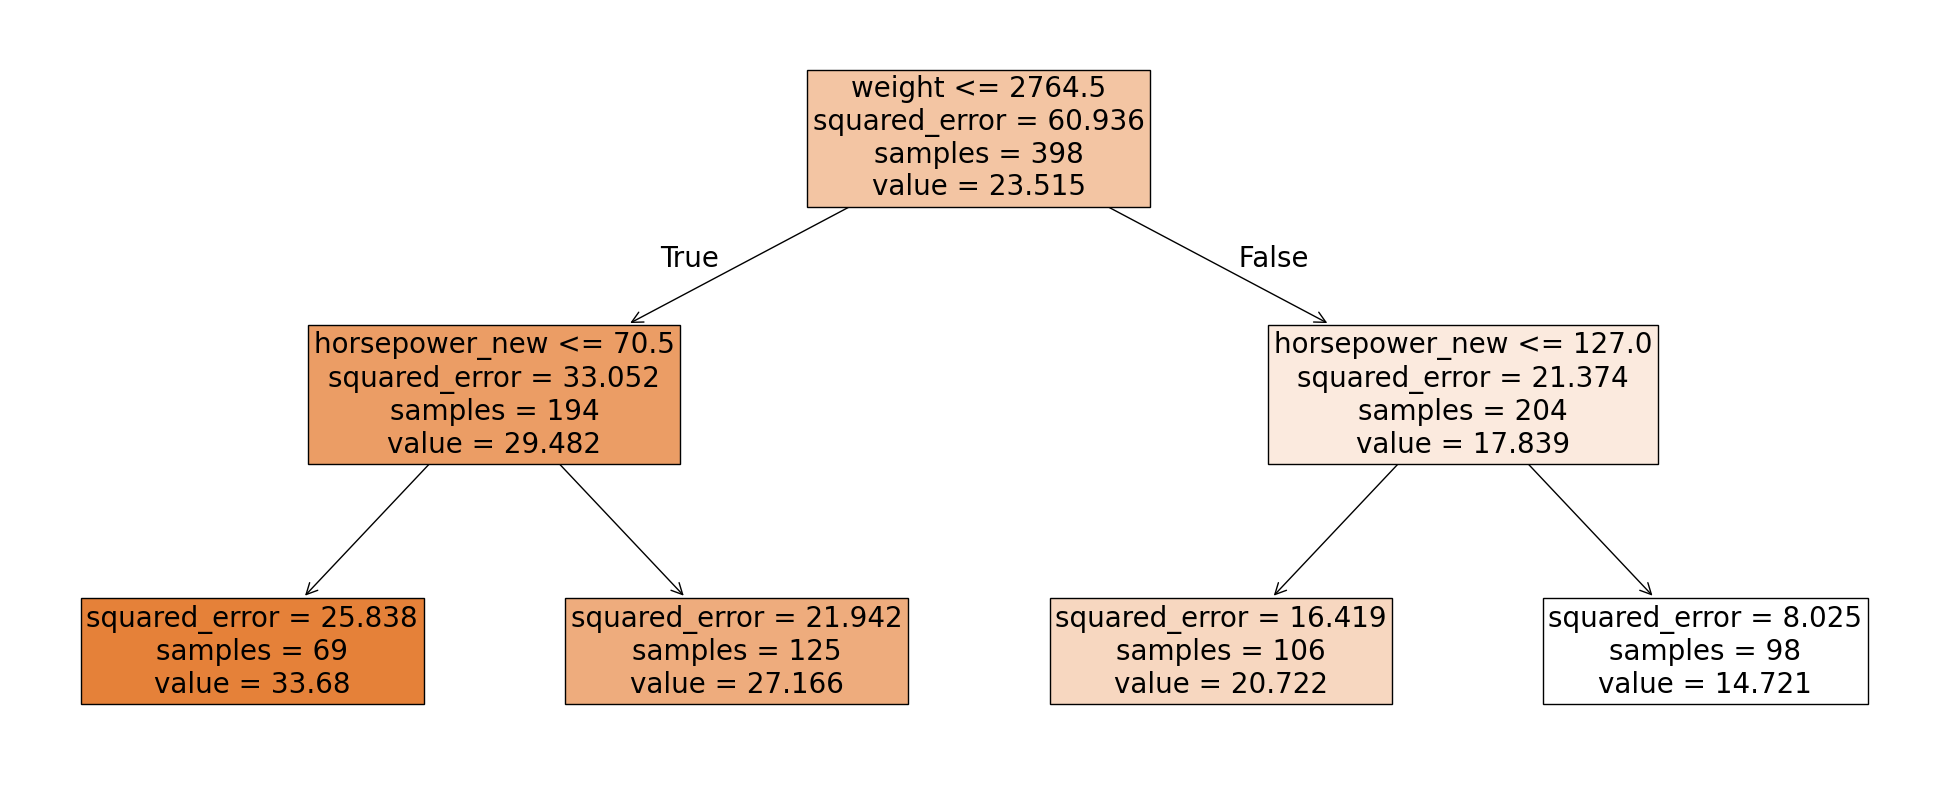

In [62]:
plt.figure(figsize=(25,10))
model8=DecisionTreeRegressor(max_depth=2, min_samples_leaf=2).fit(X7,Y7)
tree.plot_tree(model8,feature_names=X7.columns,fontsize=20,filled=True)
plt.show()

## Дерево решений (Decision Tree) с аргументами

Y9=cars['mpg']


X9=cars[['weight', 'horsepower_new','origin','displacement','cylinders', 'acceleration', 'model year']]

In [63]:
Y9=cars['mpg']
X9=cars[['weight', 'horsepower_new','origin','displacement','cylinders', 'acceleration', 'model year']]
X9_train, X9_test, Y9_train, Y9_test=train_test_split(X9, Y9, test_size=0.2, random_state=0)
dtr=DecisionTreeRegressor(max_depth=4, min_samples_leaf=3)
model9=dtr.fit(X9_train,Y9_train)
Y9_train_pred=model9.predict(X9_train)
Y9_test_pred=model9.predict(X9_test)
Models.at[QualityMetrics, 'Decision Tree_full']=[r2_score(Y9_train, Y9_train_pred),
                                                 r2_score(Y9_test, Y9_test_pred),
                                                 mean_squared_error(Y9_train, Y9_train_pred),
                                                 mean_squared_error(Y9_test, Y9_test_pred)]
Models

,LinearRegressor,NonLinearRegressor,LinearRegressor_full,NonLinearRegressor_full,Polynomial Model,Polynomial Model_full,Polynomial Model_full_Ridge,Polynomial Model_full_Lasso,Decision Tree,Decision Tree_full
R2 train,0.717325,0.799476,0.821132,0.888244,0.787744,0.957622,0.921854,0.902328,0.813091,0.887404
R2 test,0.711766,0.794014,0.828304,0.895777,0.724801,0.676829,0.896491,0.887846,0.631040,0.840413
MSE train,17.040725,15.399581,10.782819,8.068044,12.795563,2.554684,4.710927,5.888013,11.267587,6.787718
MSE test,18.290582,16.703782,10.895389,7.466817,17.463379,20.507598,6.568386,7.117001,23.413260,10.126998
Forecast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.160000,NaN


In [64]:
x_new_car=[[3000,100,2,200,5,17,76]]
y_new_car=model9.predict(x_new_car)
Models.at['Forecast','Decision Tree_full']=y_new_car.round(2)[0]
print('Прогноз расхода топлива для автомобиля весом 3000, количеством лошадиных сил 100, страной производителем -Европа, обьемом двигателя 200, количеством цилиндров в двигателе 5, разгоном 17 секунд и годом модели 76 ',y_new_car.round(2)[0])

Прогноз расхода топлива для автомобиля весом 3000, количеством лошадиных сил 100, страной производителем -Европа, обьемом двигателя 200, количеством цилиндров в двигателе 5, разгоном 17 секунд и годом модели 76  22.81


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [65]:
Models

,LinearRegressor,NonLinearRegressor,LinearRegressor_full,NonLinearRegressor_full,Polynomial Model,Polynomial Model_full,Polynomial Model_full_Ridge,Polynomial Model_full_Lasso,Decision Tree,Decision Tree_full
R2 train,0.717325,0.799476,0.821132,0.888244,0.787744,0.957622,0.921854,0.902328,0.813091,0.887404
R2 test,0.711766,0.794014,0.828304,0.895777,0.724801,0.676829,0.896491,0.887846,0.631040,0.840413
MSE train,17.040725,15.399581,10.782819,8.068044,12.795563,2.554684,4.710927,5.888013,11.267587,6.787718
MSE test,18.290582,16.703782,10.895389,7.466817,17.463379,20.507598,6.568386,7.117001,23.413260,10.126998
Forecast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.160000,22.810000


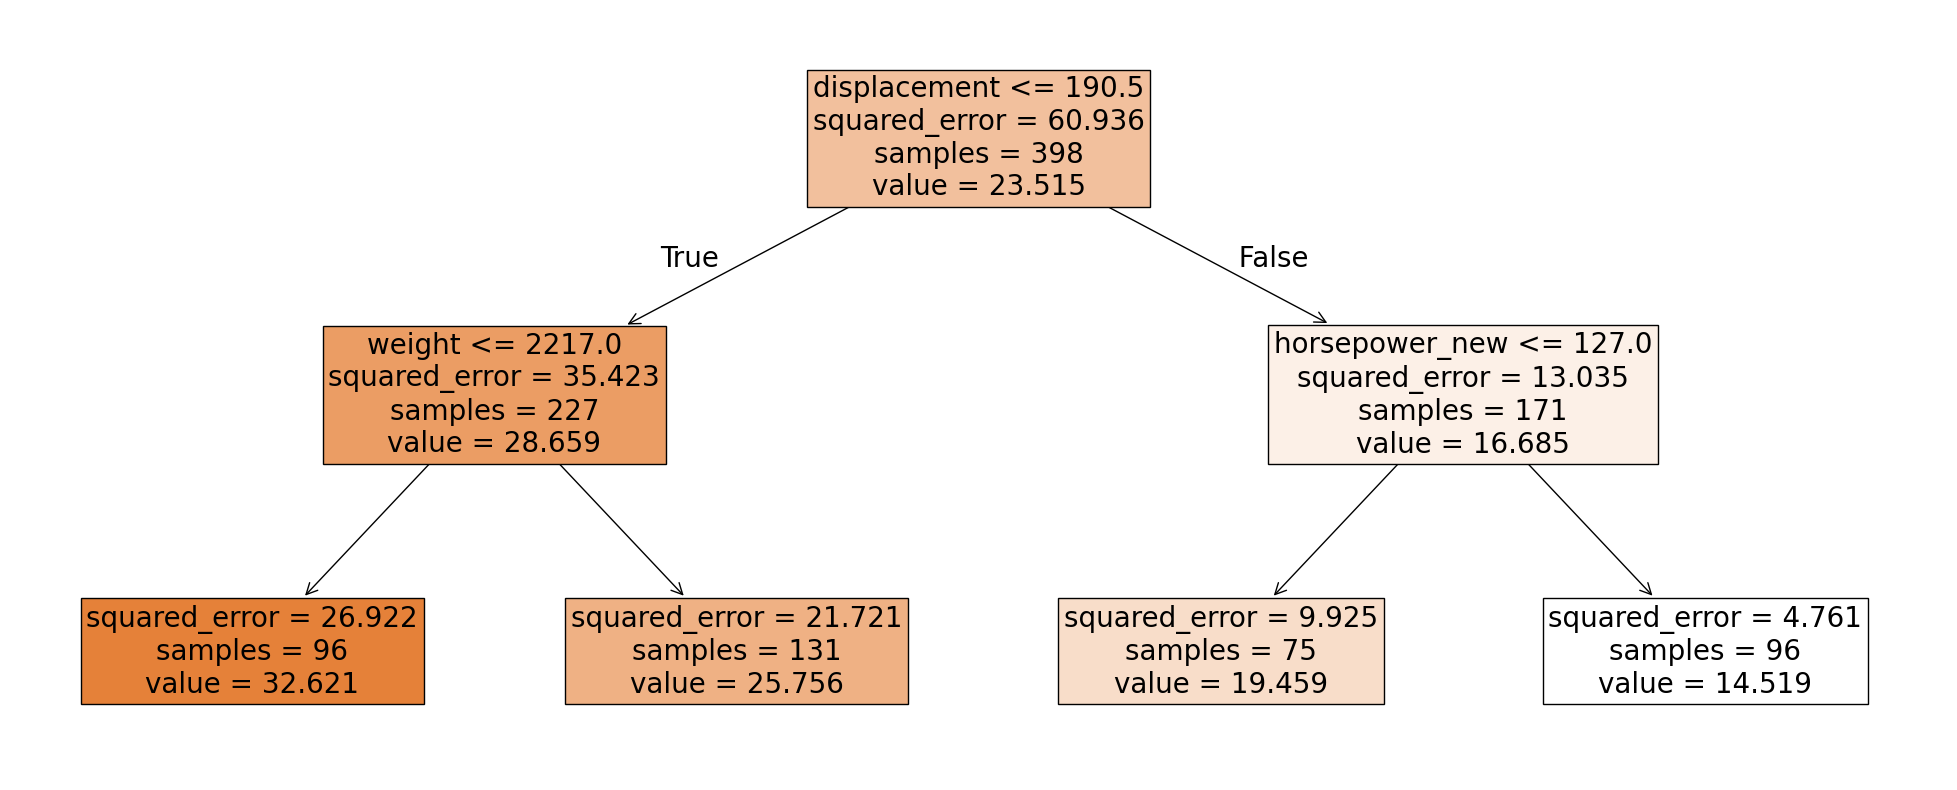

In [66]:
plt.figure(figsize=(25,10))
model10=DecisionTreeRegressor(max_depth=2, min_samples_leaf=2).fit(X9,Y9)
tree.plot_tree(model10,feature_names=X9.columns,fontsize=20,filled=True)
plt.show()

## **Вывод:**

Лучше всего себя показали **NonLinearRegressor_full**, **Polynomial Model_full** и **Decision Tree_full** — у них самые высокие значения r2_score как на обучающей, так и на тестовой выборке по сравнению с базовыми моделями.

По показателю MSE лучше всего себя показала модель **NonLinearRegressor_full**.

При этом **Polynomial Model_full** сильнее всего склонна к переобучению (заметный разрыв между R² на обучающей и тестовой выборках). Здесь и раскрывается смысл регуляризации: **Ridge** и **Lasso**, применённые именно к полиномиальным признакам, заметно сокращают этот разрыв и повышают R² на тестовой выборке — то есть регуляризация действительно улучшает обобщающую способность полиномиальной модели.

Поэтому для дальнейшего использования предпочтительны либо нелинейная модель, приведённая к линейной с помощью метода линеаризации по аргументам:

```python
Y3 = cars['mpg1']
X3 = cars[['weight1', 'displacement1', 'horsepower_new1', 'origin', 'cylinders', 'acceleration', 'model year']]
```

либо регуляризованная (Ridge) полиномиальная модель, если приоритет — на лучшем балансе между сложностью модели и устойчивостью к переобучению.


In [67]:
Models

,LinearRegressor,NonLinearRegressor,LinearRegressor_full,NonLinearRegressor_full,Polynomial Model,Polynomial Model_full,Polynomial Model_full_Ridge,Polynomial Model_full_Lasso,Decision Tree,Decision Tree_full
R2 train,0.717325,0.799476,0.821132,0.888244,0.787744,0.957622,0.921854,0.902328,0.813091,0.887404
R2 test,0.711766,0.794014,0.828304,0.895777,0.724801,0.676829,0.896491,0.887846,0.631040,0.840413
MSE train,17.040725,15.399581,10.782819,8.068044,12.795563,2.554684,4.710927,5.888013,11.267587,6.787718
MSE test,18.290582,16.703782,10.895389,7.466817,17.463379,20.507598,6.568386,7.117001,23.413260,10.126998
Forecast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.160000,22.810000
